# Camera Projection Investigation

**Goal**  
Derive the planar homography projection to the image plane, compute the Jacobian and Hessian, and connect these to the ambiguity term in EFE.

**Outline**
- Projection model (world → camera → pixels) using a homography
- Analytic Jacobian of the pixel mapping
- Hessian terms and where they blow up
- Ambiguity intuition + numerical example


## From ground-plane point to pixels


### Ground-plane point in the world frame


A point on the ground plane can be parameterized by its planar coordinates $(x,y)$ as

$$
\mathbf{p}_w(x,y)
=
\begin{bmatrix}
x \\ y \\ 0
\end{bmatrix}.
$$

To apply rigid transformations using matrix multiplication, we embed this Euclidean point
into **homogeneous coordinates** by appending a constant scale coordinate equal to 1:

$$
\tilde{\mathbf{P}}_w(x,y)
=
\begin{bmatrix}
X \\ Y \\ Z \\ 1
\end{bmatrix}
=
\begin{bmatrix}
x \\ y \\ 0 \\ 1
\end{bmatrix}.
$$

The tilde indicates that this is a homogeneous representation.
Any nonzero scalar multiple of this vector represents the same Euclidean point.

---

### 1) World $\rightarrow$ camera coordinates (extrinsic parameters)

The camera pose with respect to the world frame is described by:

- a rotation matrix $R_{cw} \in SO(3)$, mapping world axes to camera axes,
- a translation vector $t_{cw} \in \mathbb{R}^3$, giving the camera origin in world coordinates.

For a Euclidean 3D point $\mathbf{p}_w = (X,Y,Z)^\top$, the corresponding point in the
camera frame is

$$
\mathbf{p}_c
=
\begin{bmatrix}
X_c \\ Y_c \\ Z_c
\end{bmatrix}
=
R_{cw}
\begin{bmatrix}
X \\ Y \\ Z
\end{bmatrix}
+
t_{cw}.
$$

Substituting the ground-plane point $(X,Y,Z) = (x,y,0)$ yields

$$
\begin{bmatrix}
X_c \\ Y_c \\ Z_c
\end{bmatrix}
=
R_{cw}
\begin{bmatrix}
x \\ y \\ 0
\end{bmatrix}
+
t_{cw}.
$$

Writing the rotation matrix in terms of its column vectors,

$$
R_{cw} =
\begin{bmatrix}
r_1 & r_2 & r_3
\end{bmatrix},
$$

we obtain

$$
\begin{bmatrix}
X_c \\ Y_c \\ Z_c
\end{bmatrix}
=
\begin{bmatrix}
r_1 & r_2
\end{bmatrix}
\begin{bmatrix}
x \\ y
\end{bmatrix}
+
t_{cw}.
$$

Thus, when restricted to the ground plane, the camera-frame coordinates are an
**affine function** of the planar position $(x,y)$.

For later convenience, this affine mapping can be written in homogeneous form as

$$
\mathbf{p}_c(x,y)
=
\begin{bmatrix}
X_c \\ Y_c \\ Z_c
\end{bmatrix}
=
\begin{bmatrix}
r_1 & r_2 & t_{cw}
\end{bmatrix}
\begin{bmatrix}
x \\ y \\ 1
\end{bmatrix}.
$$

---

### 2) Camera coordinates $\rightarrow$ normalized image coordinates (perspective projection)

The pinhole camera model maps 3D camera-frame points to **normalized image coordinates**
by perspective division:

$$
x_n = \frac{X_c}{Z_c},
\qquad
y_n = \frac{Y_c}{Z_c}.
$$

This division by depth $Z_c$ is the fundamental nonlinearity of the camera model.
It is also the source of projective effects such as vanishing points and
state-dependent sensitivity.

---

### 3) Normalized image coordinates $\rightarrow$ pixels (intrinsic parameters)

The mapping from normalized image coordinates to pixel coordinates is described by
the camera intrinsic matrix

$$
K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix},
$$

where $f_x,f_y$ are focal lengths in pixel units and $(c_x,c_y)$ is the principal point.

In homogeneous coordinates, the projection to pixels can be written as

$$
\lambda
\begin{bmatrix}
u \\ v \\ 1
\end{bmatrix}
=
K
\begin{bmatrix}
X_c \\ Y_c \\ Z_c
\end{bmatrix},
\qquad \lambda \neq 0.
$$

The scalar $\lambda$ reflects the fact that homogeneous image coordinates are defined
only up to a nonzero scale factor.

Substituting the plane-restricted camera-frame point from step (1) gives

$$
\lambda
\begin{bmatrix}
u \\ v \\ 1
\end{bmatrix}
=
K
\begin{bmatrix}
r_1 & r_2 & t_{cw}
\end{bmatrix}
\begin{bmatrix}
x \\ y \\ 1
\end{bmatrix}.
$$

This equation shows that, for points lying on a plane, the complete mapping from
ground-plane coordinates $(x,y)$ to image pixels $(u,v)$ is linear in homogeneous
coordinates.


#### 4) Definition of the planar homography (why a 3×3 matrix is enough)

This means the entire mapping from plane coordinates to image coordinates can be represented by a single 3×3 matrix:

$$
H \triangleq K
\begin{bmatrix}
r_1 & r_2 & t_{cw}
\end{bmatrix}
\in \mathbb{R}^{3\times 3}.
$$

The matrix $H$ is called a **planar homography** (or projective transformation).
It is the *composition* of:
1) restricting the 3D world to the plane $Z=0$ (so only $(x,y)$ matter),
2) transforming that plane into the camera frame via $(R_{cw}, t_{cw})$,
3) mapping camera rays to pixels via $K$.

With this definition, the plane-to-image mapping becomes

$$
\begin{bmatrix}
u \\ v \\ 1
\end{bmatrix}
\sim
H
\begin{bmatrix}
x \\ y \\ 1
\end{bmatrix}.
$$

The symbol $\sim$ means **equality up to a nonzero scale factor**:
there exists some $\lambda \neq 0$ such that
$\lambda \begin{bmatrix} u & v & 1 \end{bmatrix}^\top = H \begin{bmatrix} x & y & 1 \end{bmatrix}^\top$.

---

#### 5) Where the denominator comes from (homogeneous $\rightarrow$ Euclidean)

The homography does not directly output Euclidean pixel coordinates $(u,v)$.
Instead, it outputs a **homogeneous image vector**:

$$
\begin{bmatrix}
\tilde{u} \\ \tilde{v} \\ \tilde{w}
\end{bmatrix}
=
H
\begin{bmatrix}
x \\ y \\ 1
\end{bmatrix}.
$$



$$
\begin{bmatrix}
\tilde{u} \\ \tilde{v} \\ \tilde{w}
\end{bmatrix}
=
\begin{bmatrix}
h_{11}x + h_{12}y + h_{13} \\
h_{21}x + h_{22}y + h_{23} \\
h_{31}x + h_{32}y + h_{33}
\end{bmatrix}.
$$

To recover Euclidean pixel coordinates, we must **dehomogenize**, i.e., divide by the last component:

$$
u = \frac{\tilde{u}}{\tilde{w}},
\qquad
v = \frac{\tilde{v}}{\tilde{w}}.
$$

This is exactly analogous to the perspective projection step
$(x_n,y_n) = (X_c/Z_c,\, Y_c/Z_c)$:
the division is what turns a linear homogeneous mapping into a nonlinear Euclidean mapping.

We define the projective denominator

$$
d(x,y) \triangleq \tilde{w} = h_{31} x + h_{32} y + h_{33}.
$$

Substituting into the dehomogenization formula yields the explicit nonlinear mapping

$$
u(x,y) =
\frac{h_{11} x + h_{12} y + h_{13}}{d(x,y)},
\qquad
v(x,y) =
\frac{h_{21} x + h_{22} y + h_{23}}{d(x,y)}.
$$

So the denominator is not an extra assumption: it is simply the last homogeneous coordinate
that must be divided out to obtain Euclidean pixels.





## How $K$, $(R_{cw},t_{cw})$, and $H$ are computed in this code

In this notebook the camera is **not calibrated from images**.  
Instead, the intrinsics and pose are **assumed** from the input parameters:

- `cam_pos`, `look_at`, `up_hint`
- `img_width`, `img_height`
- `fov_h_rad`

### A) Intrinsics $K$

The code assumes square pixels and no distortion, and computes

$$
f = \frac{W/2}{\tan(\mathrm{fov}_h/2)},\qquad
c_x = W/2,\qquad
c_y = H/2
$$

so

$$
K =
\begin{bmatrix}
f & 0 & c_x \\
0 & f & c_y \\
0 & 0 & 1
\end{bmatrix}.
$$

### B) Extrinsics $(R_{cw},t_{cw})$ from a “look‑at” construction

The rotation is built from the camera position and look‑at target:

$$
\mathbf{z}_{cam} = \frac{\text{look\_at} - \text{cam\_pos}}{\|\text{look\_at} - \text{cam\_pos}\|},
\qquad
\mathbf{x}_{cam} = \frac{\mathbf{z}_{cam} \times \text{up\_hint}}{\|\mathbf{z}_{cam} \times \text{up\_hint}\|},
\qquad
\mathbf{y}_{cam} = \mathbf{z}_{cam} \times \mathbf{x}_{cam}.
$$

Then

$$
R_{cw} =
\begin{bmatrix}
\mathbf{x}_{cam} \\
\mathbf{y}_{cam} \\
\mathbf{z}_{cam}
\end{bmatrix},
\qquad
t_{cw} = -R_{cw}\,\text{cam\_pos}.
$$

This matches the code in `PlanarCamera`.

### C) Homography $H$

For a ground plane with $Z=0$, only the first two columns of $R_{cw}$ matter:

$$
H = K \begin{bmatrix} r_1 & r_2 & t_{cw} \end{bmatrix}.
$$

This $H$ is used for the forward projection (world → pixels), and $H^{-1}$ for pixel → world.

---



In [4]:
from pathlib import Path
import sys

CWD = Path.cwd()
ROOT = CWD if (CWD / "scripts").exists() else CWD.parent
sys.path.insert(0, str(ROOT / "scripts"))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from botnav_efe_helpers import PlanarCamera, ET2, ambiguity


In [5]:
x, y = sp.symbols('x y', real=True)

h11, h12, h13 = sp.symbols('h11 h12 h13', real=True)
h21, h22, h23 = sp.symbols('h21 h22 h23', real=True)
h31, h32, h33 = sp.symbols('h31 h32 h33', real=True)

u_num = h11 * x + h12 * y + h13
v_num = h21 * x + h22 * y + h23
d = h31 * x + h32 * y + h33

u = u_num / d
v = v_num / d

J = sp.Matrix([u, v]).jacobian([x, y])
Hu = sp.hessian(u, (x, y))
Hv = sp.hessian(v, (x, y))

J_s = sp.simplify(J)
Hu_s = sp.simplify(Hu)
Hv_s = sp.simplify(Hv)

J_s, Hu_s, Hv_s


(Matrix([
 [(h11*(h31*x + h32*y + h33) - h31*(h11*x + h12*y + h13))/(h31*x + h32*y + h33)**2, (h12*(h31*x + h32*y + h33) - h32*(h11*x + h12*y + h13))/(h31*x + h32*y + h33)**2],
 [(h21*(h31*x + h32*y + h33) - h31*(h21*x + h22*y + h23))/(h31*x + h32*y + h33)**2, (h22*(h31*x + h32*y + h33) - h32*(h21*x + h22*y + h23))/(h31*x + h32*y + h33)**2]]),
 Matrix([
 [               2*h31*(-h11*(h31*x + h32*y + h33) + h31*(h11*x + h12*y + h13))/(h31*x + h32*y + h33)**3, (2*h31*h32*(h11*x + h12*y + h13) - (h11*h32 + h12*h31)*(h31*x + h32*y + h33))/(h31*x + h32*y + h33)**3],
 [(2*h31*h32*(h11*x + h12*y + h13) - (h11*h32 + h12*h31)*(h31*x + h32*y + h33))/(h31*x + h32*y + h33)**3,                2*h32*(-h12*(h31*x + h32*y + h33) + h32*(h11*x + h12*y + h13))/(h31*x + h32*y + h33)**3]]),
 Matrix([
 [               2*h31*(-h21*(h31*x + h32*y + h33) + h31*(h21*x + h22*y + h23))/(h31*x + h32*y + h33)**3, (2*h31*h32*(h21*x + h22*y + h23) - (h21*h32 + h22*h31)*(h31*x + h32*y + h33))/(h31*x + h32*y + h33)**3],

## Why the Jacobian/Hessian depend on $Z_c$ (and what $Z_c$ is)

In the pinhole model, a 3D point in the **camera frame** is
$$\mathbf{p}_c = \begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix}.$$

The image projection is
$$u = f_x \frac{X_c}{Z_c} + c_x,\qquad v = f_y \frac{Y_c}{Z_c} + c_y.$$

### What is $Z_c$?
$Z_c$ is the **depth** of the point measured along the camera’s optical axis.
- Large $Z_c$ means the point is far from the camera.
- Small $Z_c$ means the point is close to the camera.

### Why the Jacobian depends on $Z_c$
Taking derivatives of the projection gives
$$
\frac{\partial u}{\partial X_c} = \frac{f_x}{Z_c},\qquad
\frac{\partial u}{\partial Z_c} = -\frac{f_x X_c}{Z_c^2},
$$
and similarly for $v$.
So the Jacobian contains terms proportional to $1/Z_c$ and $1/Z_c^2$.
This means **pixel sensitivity increases rapidly as $Z_c$ decreases**.

### Why the Hessian depends on $Z_c$
Second derivatives introduce one more power of $Z_c$ in the denominator,
so Hessian terms scale like
$$\frac{1}{Z_c^3}.$$
This is why curvature (nonlinearity) explodes near small depth.

### How $Z_c$ is determined here
In this notebook, we compute
$$
\mathbf{p}_c = R_{cw}\,\mathbf{p}_w + t_{cw},
$$
with $\mathbf{p}_w = [x,y,0]^T$ on the ground plane.  
Then $Z_c$ is simply the **third component** of $\mathbf{p}_c$.

So in our setup, $Z_c$ is fully determined by:
- the camera pose $(R_{cw},t_{cw})$,
- and the world point $(x,y,0)$ on the ground plane.


In [6]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from botnav_efe_jax import et1_jax, et2_jax

# --- parameters ---
sigma_pos = 0.05
S = jnp.diag(jnp.array([sigma_pos**2, sigma_pos**2, sigma_pos**2]))

Z_vals = jnp.linspace(0.3, 10.0, 300)
Xc_val = 1.0
Yc_val = 0.5

# minimal params object (et1_jax/et2_jax only need R)
params = SimpleNamespace(R=jnp.zeros((2, 2)))

# camera-frame projection
def g_cam(m):
    X, Y, Z = m
    return jnp.array([fx * X / Z, fy * Y / Z])

def trace_et1_et2(Z):
    m = jnp.array([Xc_val, Yc_val, Z])
    _, Sigma1, _ = et1_jax(m, S, params, g_cam)
    _, Sigma2, _ = et2_jax(m, S, params, g_cam)
    return jnp.trace(Sigma1), jnp.trace(Sigma2)

trace_et1, trace_et2 = jax.vmap(trace_et1_et2)(Z_vals)

Z_np = np.array(Z_vals)
t1_np = np.array(trace_et1)
t2_np = np.array(trace_et2)

plt.figure(figsize=(6,4))
plt.plot(Z_np, t1_np, label="ET1 (Jacobian only)")
plt.plot(Z_np, t2_np, label="ET2 (with Hessian)")
plt.xlabel(r"$Z_c$ (depth)")
plt.ylabel(r"$\mathrm{tr}(\Sigma_o)$")
plt.title("Predicted pixel uncertainty vs depth (JAX helpers)")
plt.grid(True)
plt.legend()
plt.show()


NameError: name 'fx' is not defined

In [7]:
import numpy as np
from botnav_efe_helpers import PlanarCamera

img_width, img_height = 640, 480
fov_h_rad = np.deg2rad(90)

cam_pos = (0.0, 0.0, 3)      # 3m high
look_at = (0.0, -3, 0.0)     # looking “down and forward” (choose your direction)

cam = PlanarCamera(
    cam_pos=cam_pos,
    look_at=look_at,
    img_width=img_width,
    img_height=img_height,
    fov_h_rad=fov_h_rad,
    up_hint=(0.0, 0.0, 1.0),
)

K, R, t, H = cam.K, cam.R, cam.t, cam.H
print("K=\n", K)
print("R=\n", R)
print("t=\n", t)
print("H=\n", H)

K=
 [[320.   0. 320.]
 [  0. 320. 240.]
 [  0.   0.   1.]]
R=
 [[-1.         -0.          0.        ]
 [-0.          0.70710678 -0.70710678]
 [ 0.         -0.70710678 -0.70710678]]
t=
 [0.         2.12132034 2.12132034]
H=
 [[-3.20000000e+02 -2.26274170e+02  6.78822510e+02]
 [ 0.00000000e+00  5.65685425e+01  1.18793939e+03]
 [ 0.00000000e+00 -7.07106781e-01  2.12132034e+00]]


Footprint corners (x,y):
 [[ 16.97056275 -21.        ]
 [-16.91752974 -21.        ]
 [ -2.42111338  -0.43470483]
 [  2.42870308  -0.43470483]
 [ 16.97056275 -21.        ]]


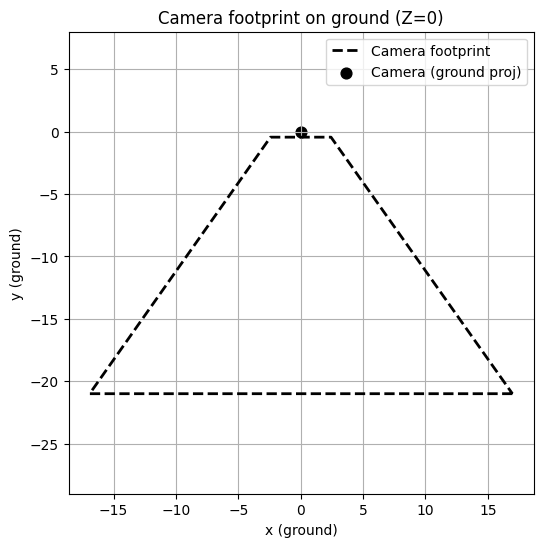

In [8]:
import matplotlib.pyplot as plt

W, Hh = img_width, img_height
corners_uv = [(0,0), (W-1,0), (W-1,Hh-1), (0,Hh-1)]

foot_xy = []
for (u,v) in corners_uv:
    x,y = cam.pixel_to_world(u,v)
    foot_xy.append([x,y])
foot_xy = np.array(foot_xy)
foot_xy = np.vstack([foot_xy, foot_xy[0]])  # close polygon

print("Footprint corners (x,y):\n", foot_xy)

plt.figure(figsize=(6,6))
plt.plot(foot_xy[:,0], foot_xy[:,1], "k--", lw=2, label="Camera footprint")
plt.scatter([cam_pos[0]], [cam_pos[1]], c="k", s=60, label="Camera (ground proj)")
plt.axis("equal"); plt.grid(True)
plt.xlabel("x (ground)"); plt.ylabel("y (ground)")
plt.legend(); plt.title("Camera footprint on ground (Z=0)")
plt.show()


Camera center C_w = [0.         0.         2.99999999]
Optical axis (world) = [ 0.         -0.70710678 -0.70710678]
Vanishing line on ground: y = 3.0

Check Zc computations:
y=-1.00 :  Zc_affine= 2.8284,  Zc_dot= 2.8284,  diff= 2.37e-09
y=-5.00 :  Zc_affine= 5.6569,  Zc_dot= 5.6569,  diff=-2.37e-09
y=-9.00 :  Zc_affine= 8.4853,  Zc_dot= 8.4853,  diff=-7.12e-09


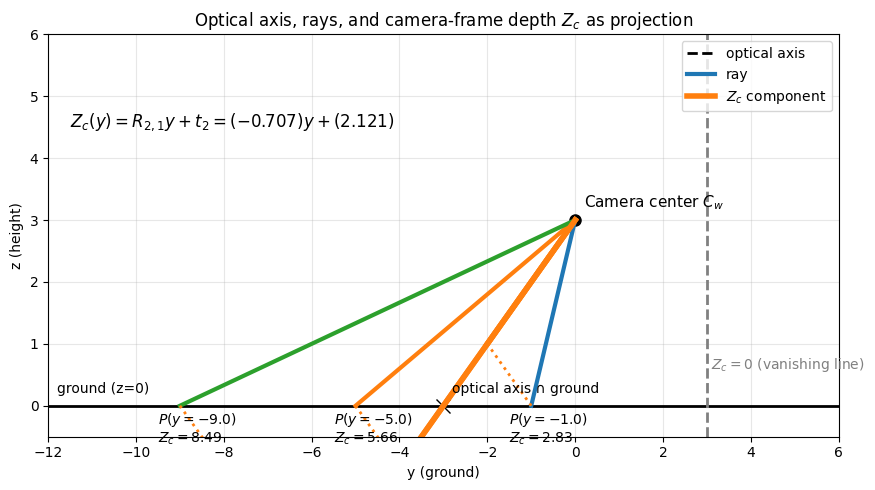

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG (easy to change)
# =========================
K = np.array([[320.,   0., 320.],
              [  0., 320., 240.],
              [  0.,   0.,   1.]])

R = np.array([[-1.,         -0.,          0.        ],
              [-0.,          0.70710678, -0.70710678],
              [ 0.,         -0.70710678, -0.70710678]])

t = np.array([0., 2.12132034, 2.12132034])

# y-values to inspect along the ground (x=0 slice)
ys = np.array([-1.0, -5.0, -9.0])

# plot limits
ymin, ymax = -12, 6
zmin, zmax = -0.5, 6


# =========================
# HELPERS
# =========================
def camera_center(R, t):
    return -R.T @ t

def optical_axis_world(R):
    z_cam_w = R.T @ np.array([0., 0., 1.])
    return z_cam_w / np.linalg.norm(z_cam_w)

def Zc_affine(R, t, y):
    # Zc = R[2,0] x + R[2,1] y + t[2]; x=0 in our slice
    return R[2,1] * y + t[2]

def line_ground_intersection(C, z_axis):
    if abs(z_axis[2]) < 1e-9:
        return None
    s = -C[2] / z_axis[2]
    return C + s * z_axis if s > 0 else None

def plot_scene(ax, C, z_axis, y_vanish, P_hit):
    # ground
    ax.plot([ymin, ymax], [0, 0], 'k-', lw=2)
    ax.text(ymin+0.2, 0.2, "ground (z=0)", fontsize=10)

    # camera
    ax.plot(C[1], C[2], 'ko', ms=8)
    ax.text(C[1]+0.2, C[2]+0.2, r"Camera center $C_w$", fontsize=11)

    # optical axis
    s_vals = np.linspace(0, 20, 200)
    opt_line = C[None,:] + s_vals[:,None] * z_axis[None,:]
    ax.plot(opt_line[:,1], opt_line[:,2], 'k--', lw=2, label="optical axis")

    # optical axis hit
    if P_hit is not None:
        ax.plot(P_hit[1], 0, 'kx', ms=10)
        ax.text(P_hit[1]+0.2, 0.2, "optical axis ∩ ground", fontsize=10)

    # vanishing line
    ax.axvline(y_vanish, color='gray', ls='--', lw=2)
    ax.text(y_vanish+0.1, 0.6, r"$Z_c=0$ (vanishing line)", color='gray', fontsize=10)


# =========================
# COMPUTE GEOMETRY
# =========================
C = camera_center(R, t)
z_cam_in_world = optical_axis_world(R)
y_vanish = -t[2] / R[2,1]
P_hit = line_ground_intersection(C, z_cam_in_world)

print("Camera center C_w =", C)
print("Optical axis (world) =", z_cam_in_world)
print("Vanishing line on ground: y =", y_vanish)

# points on ground (x=0 slice)
Pts = np.stack([np.zeros_like(ys), ys, np.zeros_like(ys)], axis=1)
Zc1 = np.array([Zc_affine(R, t, y) for y in ys])
Zc2 = np.array([np.dot(z_cam_in_world, (P - C)) for P in Pts])

print("\nCheck Zc computations:")
for y, a, b in zip(ys, Zc1, Zc2):
    print(f"y={y: .2f} :  Zc_affine={a: .4f},  Zc_dot={b: .4f},  diff={a-b: .2e}")

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(9, 5))
plot_scene(ax, C, z_cam_in_world, y_vanish, P_hit)

# Rays and Zc components
for i, (P, y, zc) in enumerate(zip(Pts, ys, Zc1)):
    # ray
    ax.plot([C[1], P[1]], [C[2], P[2]], lw=3, label="ray" if i==0 else None)

    # projection onto optical axis
    s_proj = np.dot(z_cam_in_world, (P - C))
    P_proj = C + s_proj * z_cam_in_world

    ax.plot([C[1], P_proj[1]], [C[2], P_proj[2]],
            color='tab:orange', lw=4, label=r"$Z_c$ component" if i==0 else None)
    ax.plot([P[1], P_proj[1]], [P[2], P_proj[2]],
            color='tab:orange', ls=':', lw=2)

    ax.text(P[1]-0.5, P[2]-0.6,
            rf"$P(y={y:.1f})$"+"\n"+rf"$Z_c={zc:.2f}$",
            fontsize=10)

# formula annotation
ax.text(ymin+0.5, zmax-1.5,
        rf"$Z_c(y)=R_{{2,1}}y+t_2 = ({R[2,1]:.3f})y + ({t[2]:.3f})$",
        fontsize=12)

ax.set_xlim(ymin, ymax)
ax.set_ylim(zmin, zmax)
ax.set_xlabel("y (ground)")
ax.set_ylabel("z (height)")
ax.set_title("Optical axis, rays, and camera-frame depth $Z_c$ as projection")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


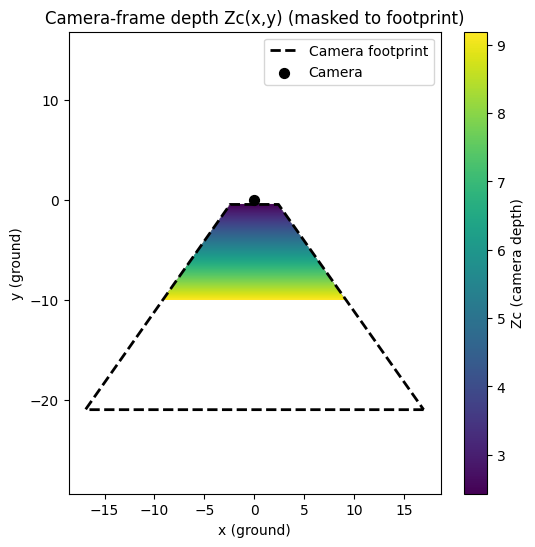

In [10]:
from matplotlib.path import Path

xmin, xmax = -10, 10
ymin, ymax = -10, 10
nx, ny = 300, 300
xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xs, ys)


poly = Path(foot_xy[:-1])  
inside = poly.contains_points(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

Zc = R[2,0]*X + R[2,1]*Y + t[2]

valid = inside & (Zc > 1e-6)

Zc_plot = np.where(valid, Zc, np.nan)

plt.figure(figsize=(6,6))
plt.imshow(Zc_plot, extent=[xmin,xmax,ymin,ymax], origin="lower")
plt.colorbar(label="Zc (camera depth)")
plt.plot(foot_xy[:,0], foot_xy[:,1], "k--", lw=2, label="Camera footprint")
plt.scatter([cam_pos[0]], [cam_pos[1]], c="k", s=50, label="Camera")
plt.axis("equal"); plt.grid(False)
plt.xlabel("x (ground)"); plt.ylabel("y (ground)")
plt.legend(); plt.title("Camera-frame depth Zc(x,y) (masked to footprint)")
plt.show()


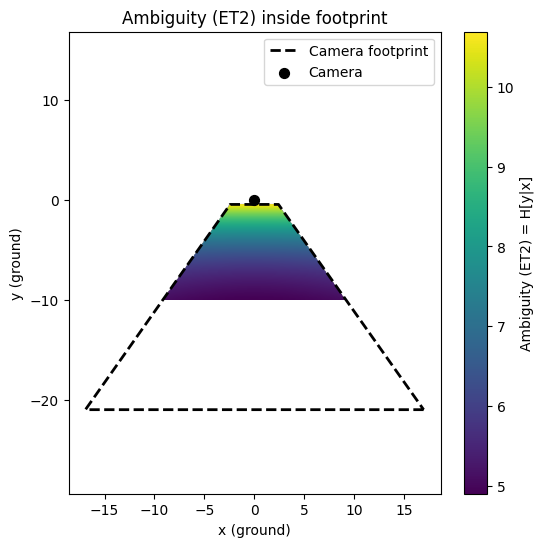

In [14]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from botnav_efe_jax import et2_jax, ambiguity_jax, make_homography_g_jax

# --- inputs (same as before) ---
sx, sy = 1, 1
svx, svy = 0.50, 0.50
S = jnp.diag(jnp.array([sx**2, sy**2, svx**2, svy**2]))

sigma_pix = 2.0
R_meas = jnp.diag(jnp.array([sigma_pix**2, sigma_pix**2]))

g_jax = make_homography_g_jax(cam.H)
params = SimpleNamespace(R=R_meas)

# --- vectorized ambiguity ---
def amb_one(m):
    _, Sigma, Gamma = et2_jax(m, S, params, g_jax)
    return ambiguity_jax(Sigma, Gamma, S)

amb_batch = jax.jit(jax.vmap(amb_one))  # compile once

# --- flatten grid and evaluate in one shot ---
Xf = jnp.asarray(X.ravel())
Yf = jnp.asarray(Y.ravel())
Mf = jnp.stack([Xf, Yf, jnp.zeros_like(Xf), jnp.zeros_like(Xf)], axis=1)

amb_flat = amb_batch(Mf)
amb = np.array(amb_flat).reshape(X.shape)

Amb = np.where(valid, amb, np.nan)

plt.figure(figsize=(6,6))
plt.imshow(Amb, extent=[xmin,xmax,ymin,ymax], origin="lower")
plt.colorbar(label="Ambiguity (ET2) = H[y|x]")
plt.plot(foot_xy[:,0], foot_xy[:,1], "k--", lw=2, label="Camera footprint")
plt.scatter([cam_pos[0]], [cam_pos[1]], c="k", s=50, label="Camera")
plt.axis("equal")
plt.xlabel("x (ground)"); plt.ylabel("y (ground)")
plt.legend(); plt.title("Ambiguity (ET2) inside footprint")
plt.show()


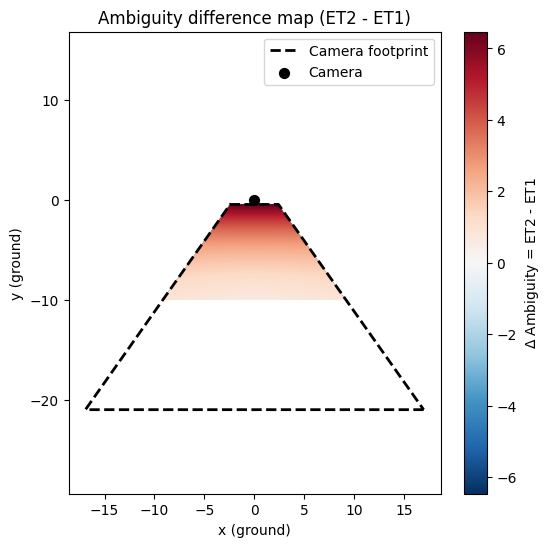

In [15]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from botnav_efe_jax import et1_jax, et2_jax, ambiguity_jax, make_homography_g_jax

# --- inputs (same as before) ---
sx, sy = 1, 1
svx, svy = 0.50, 0.50
S = jnp.diag(jnp.array([sx**2, sy**2, svx**2, svy**2]))

sigma_pix = 2.0
R_meas = jnp.diag(jnp.array([sigma_pix**2, sigma_pix**2]))

g_jax = make_homography_g_jax(cam.H)
params = SimpleNamespace(R=R_meas)

# returns [amb_ET1, amb_ET2, amb_ET2-amb_ET1]
def amb_pair(m):
    _, Sigma1, Gamma1 = et1_jax(m, S, params, g_jax)
    _, Sigma2, Gamma2 = et2_jax(m, S, params, g_jax)
    a1 = ambiguity_jax(Sigma1, Gamma1, S)
    a2 = ambiguity_jax(Sigma2, Gamma2, S)
    return jnp.stack([a1, a2, a2 - a1])

amb_batch = jax.jit(jax.vmap(amb_pair))

# --- flatten grid and evaluate in one shot ---
Xf = jnp.asarray(X.ravel())
Yf = jnp.asarray(Y.ravel())
Mf = jnp.stack([Xf, Yf, jnp.zeros_like(Xf), jnp.zeros_like(Xf)], axis=1)

amb_all = np.array(amb_batch(Mf))  # (N, 3)
delta = amb_all[:, 2].reshape(X.shape)

Delta = np.where(valid, delta, np.nan)

# symmetric color scale around 0
v = np.nanmax(np.abs(Delta))
v = 1e-12 if not np.isfinite(v) or v == 0 else v

plt.figure(figsize=(6, 6))
plt.imshow(Delta, extent=[xmin, xmax, ymin, ymax], origin="lower",
           cmap="RdBu_r", vmin=-v, vmax=v)
plt.colorbar(label=r"$\Delta$ Ambiguity = ET2 - ET1")
plt.plot(foot_xy[:, 0], foot_xy[:, 1], "k--", lw=2, label="Camera footprint")
plt.scatter([cam_pos[0]], [cam_pos[1]], c="k", s=50, label="Camera")
plt.axis("equal")
plt.xlabel("x (ground)")
plt.ylabel("y (ground)")
plt.legend()
plt.title("Ambiguity difference map (ET2 - ET1)")
plt.show()


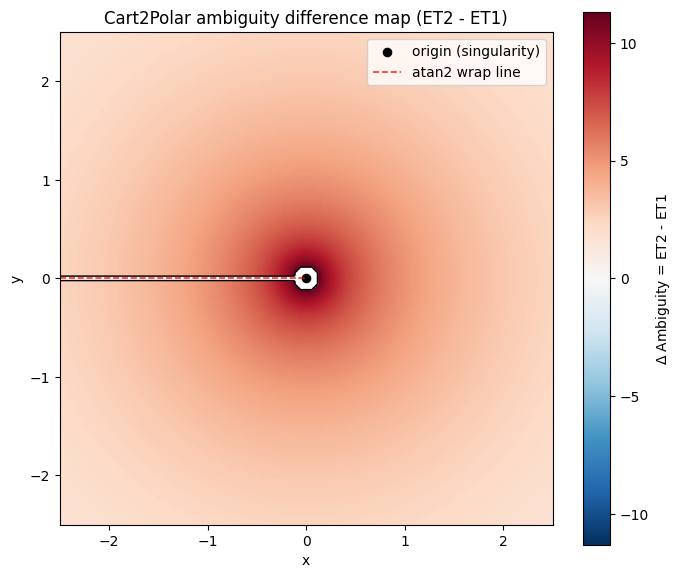

In [16]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from botnav_efe_jax import et1_jax, et2_jax, ambiguity_jax

# ----------------------------
# cart2polar observation (x,y -> r,phi)
# ----------------------------
def g_cart2polar_jax(state4):
    x, y = state4[0], state4[1]
    r = jnp.sqrt(x * x + y * y + 1e-12)
    phi = jnp.arctan2(y, x)
    return jnp.stack([r, phi])

# Belief covariance in latent state [x, y, vx, vy]
sx, sy = 1.0, 1.0
svx, svy = 0.5, 0.5
S = jnp.diag(jnp.array([sx**2, sy**2, svx**2, svy**2]))

# Measurement noise in [r, phi]
sigma_r = 0.05
sigma_phi = np.deg2rad(5.0)
R_meas = jnp.diag(jnp.array([sigma_r**2, sigma_phi**2]))
params = SimpleNamespace(R=R_meas)

# Grid
xmin, xmax, ymin, ymax = -2.5, 2.5, -2.5, 2.5
nx, ny = 220, 220
xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xs, ys)

# Mask singular/problematic regions (origin + branch-cut neighborhood)
Rxy = np.sqrt(X**2 + Y**2)
valid = Rxy > 0.12
valid &= ~((X < 0.0) & (np.abs(Y) < 0.03))  # near atan2 wrap line

def amb_pair(m):
    _, Sigma1, Gamma1 = et1_jax(m, S, params, g_cart2polar_jax)
    _, Sigma2, Gamma2 = et2_jax(m, S, params, g_cart2polar_jax)
    a1 = ambiguity_jax(Sigma1, Gamma1, S)
    a2 = ambiguity_jax(Sigma2, Gamma2, S)
    return jnp.stack([a1, a2, a2 - a1])

amb_batch = jax.jit(jax.vmap(amb_pair))

# Evaluate
Xf = jnp.asarray(X.ravel())
Yf = jnp.asarray(Y.ravel())
Mf = jnp.stack([Xf, Yf, jnp.zeros_like(Xf), jnp.zeros_like(Xf)], axis=1)
out = np.array(amb_batch(Mf))  # shape (N, 3)

delta = out[:, 2].reshape(X.shape)
Delta = np.where(valid, delta, np.nan)

# Symmetric color scale
v = np.nanmax(np.abs(Delta))
v = 1e-9 if (not np.isfinite(v) or v == 0.0) else v

plt.figure(figsize=(7, 6))
plt.imshow(
    Delta,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="RdBu_r",
    vmin=-v, vmax=v,
    aspect="equal",
)
plt.colorbar(label=r"$\Delta$ Ambiguity = ET2 - ET1")
plt.contour(X, Y, valid.astype(float), levels=[0.5], colors="k", linewidths=1.0)
plt.scatter([0.0], [0.0], c="k", s=35, label="origin (singularity)")
plt.plot([xmin, 0.0], [0.0, 0.0], "r--", lw=1.2, alpha=0.8, label="atan2 wrap line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cart2Polar ambiguity difference map (ET2 - ET1)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


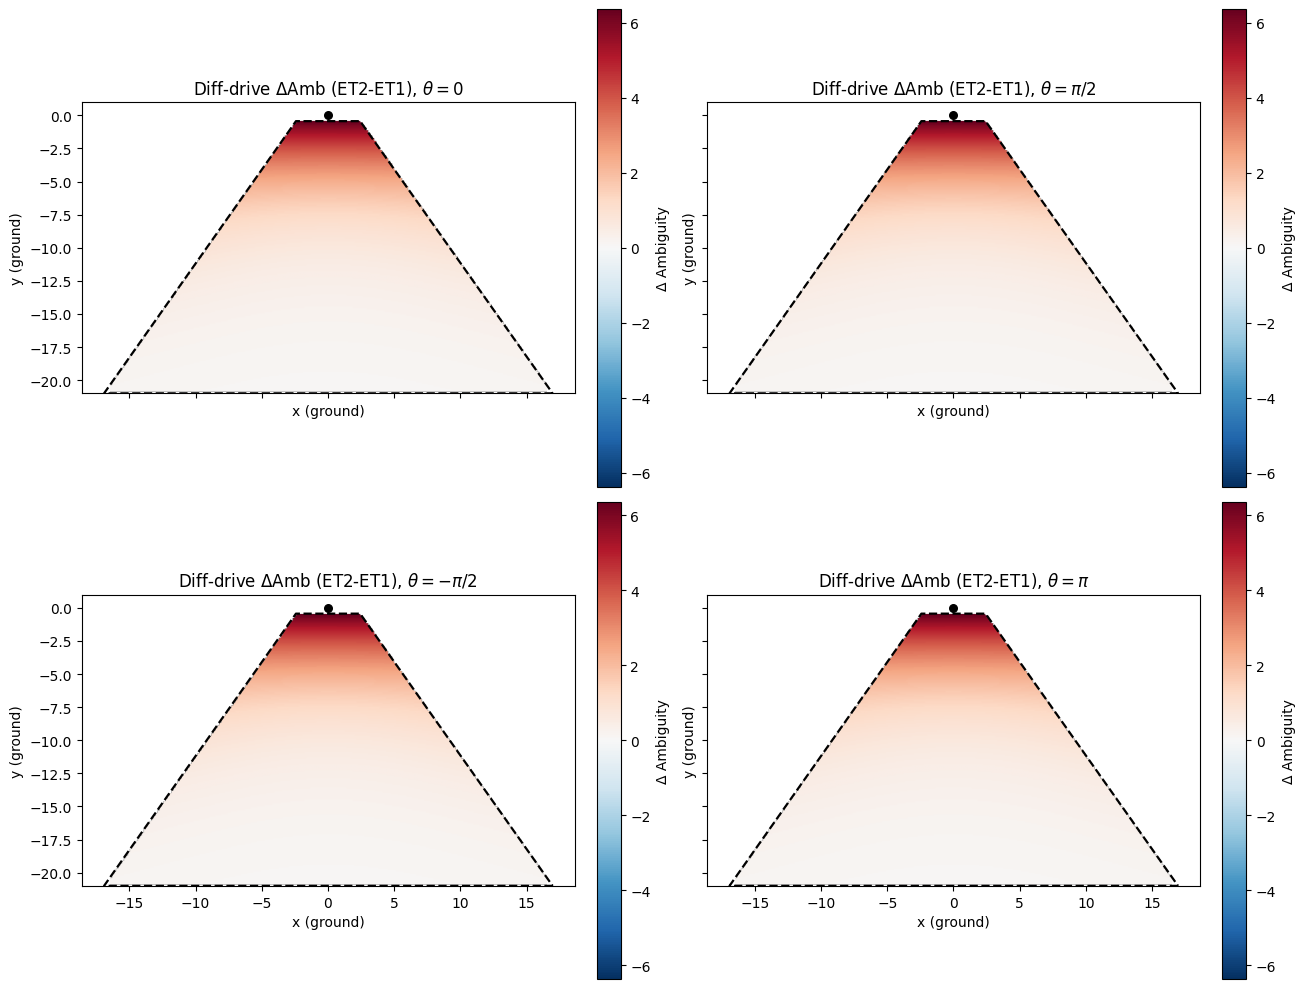

In [17]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from botnav_efe_jax import et1_jax, et2_jax, ambiguity_jax, make_homography_g_jax

# ---- assumes cam already exists (PlanarCamera) ----
g_jax = make_homography_g_jax(cam.H)

# Unicycle latent covariance S in [x,y,theta]
sx, sy = 1.0, 1.0
st = np.deg2rad(12.0)
S_uni = jnp.diag(jnp.array([sx**2, sy**2, st**2]))

sigma_pix = 2.0
R_meas = jnp.diag(jnp.array([sigma_pix**2, sigma_pix**2]))
params = SimpleNamespace(R=R_meas)

# Grid in world plane
xmin, xmax, ymin, ymax = -16.5, 16.5, -21.0, 1.0
nx, ny = 220, 220
xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xs, ys)

# Optional: mask to camera footprint if you have foot_xy
valid = np.ones_like(X, dtype=bool)
try:
    from matplotlib.path import Path as MplPath
    if foot_xy.shape[0] >= 4:
        poly = MplPath(foot_xy[:-1]) if np.allclose(foot_xy[0], foot_xy[-1]) else MplPath(foot_xy)
        valid = poly.contains_points(np.column_stack([X.ravel(), Y.ravel()])).reshape(X.shape)
except Exception:
    pass

# ET2-ET1 ambiguity at fixed theta
def amb_delta_uni(m):
    _, S1, G1 = et1_jax(m, S_uni, params, g_jax)
    _, S2, G2 = et2_jax(m, S_uni, params, g_jax)
    return ambiguity_jax(S2, G2, S_uni) - ambiguity_jax(S1, G1, S_uni)

amb_delta_batch = jax.jit(jax.vmap(amb_delta_uni))

theta_slices = [0.0, np.pi/2, -np.pi/2, np.pi]  # pick headings you care about
titles = [r"$\theta=0$", r"$\theta=\pi/2$", r"$\theta=-\pi/2$", r"$\theta=\pi$"]

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)

for ax, th, ttl in zip(axes.ravel(), theta_slices, titles):
    Xf = jnp.asarray(X.ravel())
    Yf = jnp.asarray(Y.ravel())
    Tf = jnp.full_like(Xf, float(th))
    Mf = jnp.stack([Xf, Yf, Tf], axis=1)

    delta = np.array(amb_delta_batch(Mf)).reshape(X.shape)
    Delta = np.where(valid, delta, np.nan)

    v = np.nanmax(np.abs(Delta))
    v = 1e-9 if (not np.isfinite(v) or v == 0.0) else float(v)

    im = ax.imshow(
        Delta,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        cmap="RdBu_r",
        vmin=-v, vmax=v,
        aspect="equal",
    )

    if "foot_xy" in globals() and foot_xy.shape[0] >= 2:
        ax.plot(foot_xy[:, 0], foot_xy[:, 1], "k--", lw=1.6)
    if "cam_pos" in globals():
        ax.scatter([cam_pos[0]], [cam_pos[1]], c="k", s=30)

    ax.set_title(f"Diff-drive ΔAmb (ET2-ET1), {ttl}")
    ax.set_xlabel("x (ground)")
    ax.set_ylabel("y (ground)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Δ Ambiguity")

fig.tight_layout()
plt.show()


## 15° setup at 2m: rough-footprint $1/Z_c^3$ vs ambiguity

For shallow cameras the exact ground footprint can become numerically fragile.
This cell uses a **rough rectangular ROI** (not the exact projected polygon) around the region of interest in front of the camera,
then compares:
- $1/Z_c^3$ (curvature scaling proxy),
- ET2 ambiguity,
- and the $Z_c^3$-scaled ambiguity ($\mathrm{Amb}\cdot Z_c^3$).


/tmp/ipykernel_62902/501766055.py:77: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  S = jnp.diag(jnp.array([sx**2, sy**2, svx**2, svy**2], dtype=jnp.float64))
/tmp/ipykernel_62902/501766055.py:80: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  R_meas = jnp.diag(jnp.array([sigma_pix**2, sigma_pix**2], dtype=jnp.float64))


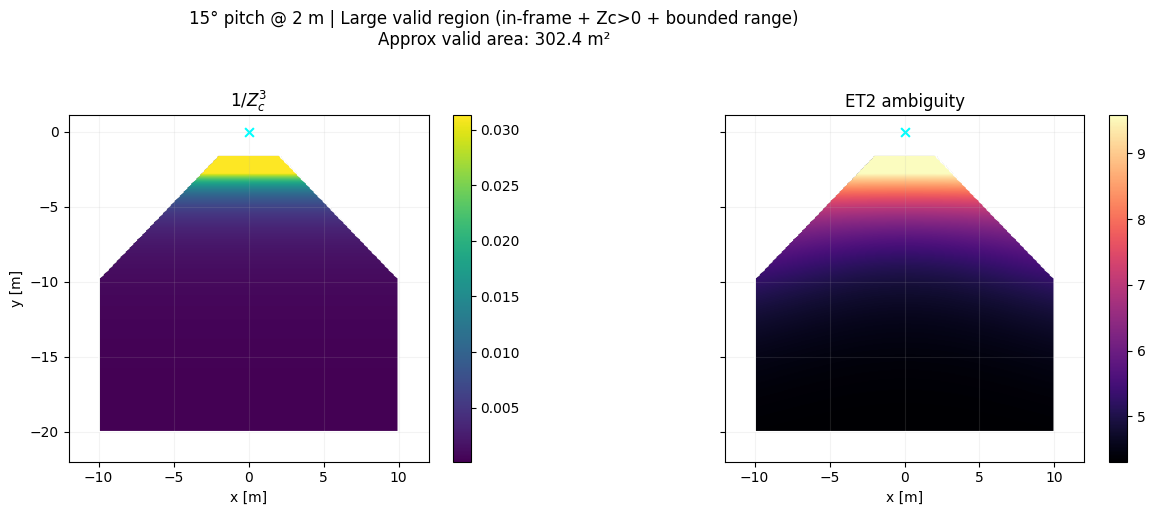

valid cells: 51676
forward range in valid area: 1.59 .. 19.96 m
max |lateral| in valid area: 9.94 m
mean(1/Zc^3): 0.00295417
mean(ambiguity): 5.17669


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from types import SimpleNamespace

from botnav_efe_helpers import PlanarCamera
from botnav_efe_jax import et2_jax, ambiguity_jax, make_homography_g_jax

# --- Camera: 15 deg down, 2 m height ---
img_width, img_height = 640, 480
fov_h_rad = np.deg2rad(90.0)

pitch_deg = 15.0
h_cam = 2.0
pitch = np.deg2rad(pitch_deg)

cam_pos = np.array([0.0, 0.0, h_cam], dtype=float)
view_dir = np.array([0.0, -np.cos(pitch), -np.sin(pitch)], dtype=float)
look_at = cam_pos + 5.0 * view_dir

cam15 = PlanarCamera(
    cam_pos=cam_pos,
    look_at=look_at,
    img_width=img_width,
    img_height=img_height,
    fov_h_rad=fov_h_rad,
    up_hint=(0.0, 0.0, 1.0),
)

R15, t15, H15 = cam15.R, cam15.t, cam15.H

# --- Large, informative world grid ---
xmin, xmax = -12.0, 12.0
ymin, ymax = -22.0, -0.3
nx, ny = 280, 320  # increase/decrease for detail/speed tradeoff

xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xs, ys)

# --- Project grid through homography to get in-frame mask ---
P = np.stack([X.ravel(), Y.ravel(), np.ones(X.size)], axis=0)  # 3 x N
UVW = H15 @ P
W = UVW[2]
u = (UVW[0] / W).reshape(X.shape)
v = (UVW[1] / W).reshape(X.shape)

in_frame = (
    np.isfinite(u) & np.isfinite(v) &
    (u >= 0.0) & (u < img_width) &
    (v >= 0.0) & (v < img_height)
)

# Positive camera depth on ground Z=0
Zc = R15[2, 0] * X + R15[2, 1] * Y + t15[2]
positive_depth = Zc > 1e-6

# Additional world-space bounds so the area is large but meaningful
fwd_xy = np.array([view_dir[0], view_dir[1]], dtype=float)
fwd_xy = fwd_xy / (np.linalg.norm(fwd_xy) + 1e-12)
dx = X - cam_pos[0]
dy = Y - cam_pos[1]
forward = dx * fwd_xy[0] + dy * fwd_xy[1]
lateral = -dx * fwd_xy[1] + dy * fwd_xy[0]

roi = (forward >= 0.5) & (forward <= 20.0) & (np.abs(lateral) <= 10.0)

valid = in_frame & positive_depth & roi

# --- 1 / Zc^3 ---
inv_zc3 = np.where(valid, 1.0 / (Zc ** 3), np.nan)

# --- ET2 ambiguity ---
sx, sy = 1.0, 1.0
svx, svy = 0.5, 0.5
S = jnp.diag(jnp.array([sx**2, sy**2, svx**2, svy**2], dtype=jnp.float64))

sigma_pix = 2.0
R_meas = jnp.diag(jnp.array([sigma_pix**2, sigma_pix**2], dtype=jnp.float64))

g_jax_15 = make_homography_g_jax(cam15.H)
params_15 = SimpleNamespace(R=R_meas)

def amb_one(m):
    _, Sigma, Gamma = et2_jax(m, S, params_15, g_jax_15)
    return ambiguity_jax(Sigma, Gamma, S)

amb_batch = jax.jit(jax.vmap(amb_one))

Amb_flat = np.full(X.size, np.nan, dtype=float)
idx = np.where(valid.ravel())[0]
if idx.size > 0:
    Mf = jnp.stack([
        jnp.asarray(X.ravel()[idx]),
        jnp.asarray(Y.ravel()[idx]),
        jnp.zeros(idx.size),
        jnp.zeros(idx.size)
    ], axis=1)
    Amb_flat[idx] = np.array(amb_batch(Mf), dtype=float)

Amb = Amb_flat.reshape(X.shape)

def robust_limits(a, qlo=2, qhi=98):
    vals = a[np.isfinite(a)]
    if vals.size == 0:
        return None, None
    vmin, vmax = np.percentile(vals, [qlo, qhi])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        return None, None
    return float(vmin), float(vmax)

vmin1, vmax1 = robust_limits(inv_zc3)
vmin2, vmax2 = robust_limits(Amb)

# --- Plot only the two requested maps ---
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharex=True, sharey=True)

im1 = axes[0].imshow(
    inv_zc3, extent=[xmin, xmax, ymin, ymax], origin="lower",
    cmap="viridis", vmin=vmin1, vmax=vmax1
)
axes[0].set_title(r"$1/Z_c^3$")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(
    Amb, extent=[xmin, xmax, ymin, ymax], origin="lower",
    cmap="magma", vmin=vmin2, vmax=vmax2
)
axes[1].set_title("ET2 ambiguity")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Overlay valid-area boundary and camera projection
for ax in axes:
    ax.contour(X, Y, valid.astype(float), levels=[0.5], colors="white", linewidths=1.0)
    ax.scatter([cam_pos[0]], [cam_pos[1]], c="cyan", marker="x", s=40)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.grid(alpha=0.15)

axes[0].set_ylabel("y [m]")

cell_area = ((xmax - xmin) / (nx - 1)) * ((ymax - ymin) / (ny - 1))
area_valid = float(np.sum(valid) * cell_area)
fig.suptitle(
    f"15° pitch @ 2 m | Large valid region (in-frame + Zc>0 + bounded range)\n"
    f"Approx valid area: {area_valid:.1f} m²",
    y=1.02
)
fig.tight_layout()
plt.show()

if np.any(valid):
    fwd_min = float(np.nanmin(np.where(valid, forward, np.nan)))
    fwd_max = float(np.nanmax(np.where(valid, forward, np.nan)))
    lat_max = float(np.nanmax(np.abs(np.where(valid, lateral, np.nan))))
    print(f"valid cells: {int(np.sum(valid))}")
    print(f"forward range in valid area: {fwd_min:.2f} .. {fwd_max:.2f} m")
    print(f"max |lateral| in valid area: {lat_max:.2f} m")
    print(f"mean(1/Zc^3): {float(np.nanmean(inv_zc3)):.6g}")
    print(f"mean(ambiguity): {float(np.nanmean(Amb)):.6g}")
else:
    print("No valid cells found. Expand grid or relax ROI bounds.")
